生成数据

In [1]:
import pandas as pd
import numpy as np

# 创建辛普森悖论数据
data = {
    '地图': ['简单']*110 + ['困难']*110,
    '队伍': ['A']*110 + ['B']*110,
    '比赛场次': [10]*10 + [100]*10 + [100]*10 + [10]*10,
    '胜率': [0.9]*10 + [0.6]*10 + [0.8]*10 + [0.5]*10
}

# 实际数据
df_simple = pd.DataFrame({
    '地图': ['简单']*110,
    '队伍': ['A']*10 + ['B']*100,
    '结果': [1]*9 + [0]*1 + [1]*80 + [0]*20  # A:9胜1负, B:80胜20负
})

df_hard = pd.DataFrame({
    '地图': ['困难']*110,
    '队伍': ['A']*100 + ['B']*10,
    '结果': [1]*60 + [0]*40 + [1]*5 + [0]*5  # A:60胜40负, B:5胜5负
})

df = pd.concat([df_simple, df_hard], ignore_index=True)
df['结果'] = df['结果'].map({1: '胜', 0: '负'})

print("数据预览：")
print(df.head(10))
print(f"\n总数据量：{len(df)}")


数据预览：
   地图 队伍 结果
0  简单  A  胜
1  简单  A  胜
2  简单  A  胜
3  简单  A  胜
4  简单  A  胜
5  简单  A  胜
6  简单  A  胜
7  简单  A  胜
8  简单  A  胜
9  简单  A  负

总数据量：220


计算分组胜率


In [2]:
# 按地图和队伍分组计算胜率
grouped = df.groupby(['地图', '队伍'])['结果'].apply(lambda x: (x == '胜').mean()).reset_index()
grouped.columns = ['地图', '队伍', '胜率']
grouped['胜率'] = grouped['胜率'].apply(lambda x: f"{x:.1%}")

print("分组胜率：")
print(grouped.pivot(index='地图', columns='队伍', values='胜率'))

# 计算总胜率
total = df.groupby('队伍')['结果'].apply(lambda x: (x == '胜').mean()).reset_index()
total.columns = ['队伍', '总胜率']
total['总胜率'] = total['总胜率'].apply(lambda x: f"{x:.1%}")

print("\n总胜率：")
print(total)

分组胜率：
队伍      A      B
地图              
困难  60.0%  50.0%
简单  90.0%  80.0%

总胜率：
  队伍    总胜率
0  A  62.7%
1  B  77.3%


可视化

C:\Temp\ipykernel_202184\1399769082.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  grouped_pivot = grouped_pivot.applymap(lambda x: float(x.strip('%'))/100)


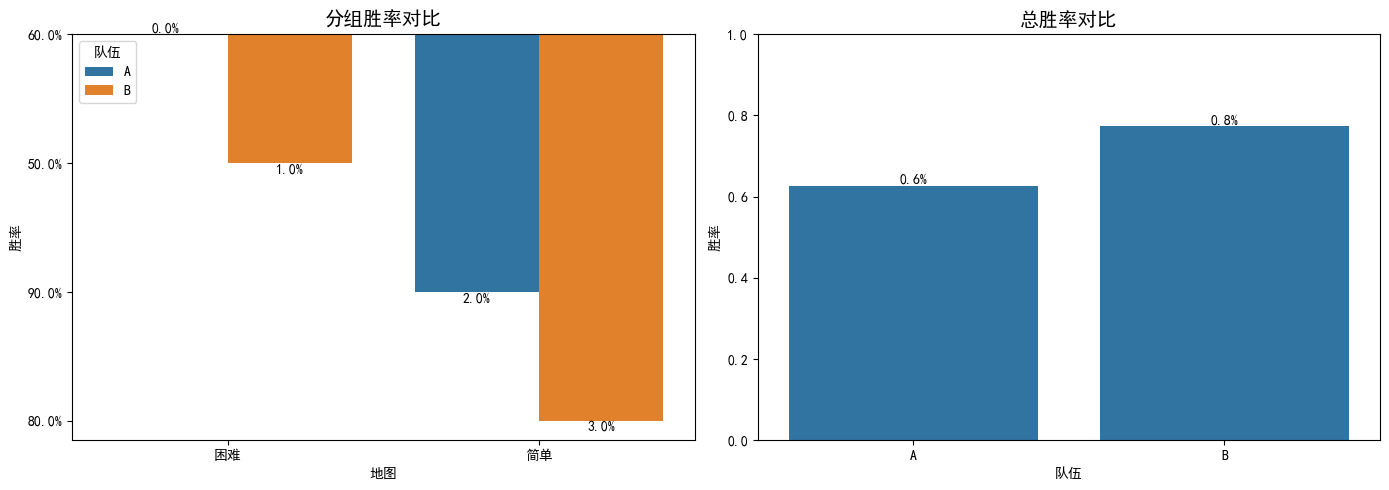


图表已保存为 'simpson_paradox.png'


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 图1：分组胜率
grouped_pivot = grouped.pivot(index='地图', columns='队伍', values='胜率')
grouped_pivot = grouped_pivot.applymap(lambda x: float(x.strip('%'))/100)

sns.barplot(data=grouped, x='地图', y='胜率', hue='队伍', ax=axes[0])
axes[0].set_title('分组胜率对比', fontsize=14, fontweight='bold')
axes[0].set_ylabel('胜率')
for i in axes[0].containers:
    axes[0].bar_label(i, fmt='%.1f%%')

# 图2：总胜率
total_plot = total.copy()
total_plot['总胜率'] = total_plot['总胜率'].apply(lambda x: float(x.strip('%'))/100)

sns.barplot(data=total_plot, x='队伍', y='总胜率', ax=axes[1])
axes[1].set_title('总胜率对比', fontsize=14, fontweight='bold')
axes[1].set_ylabel('胜率')
axes[1].set_ylim(0, 1)
for i in axes[1].containers:
    axes[1].bar_label(i, fmt='%.1f%%')

plt.tight_layout()
plt.savefig('simpson_paradox.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n图表已保存为 'simpson_paradox.png'")